## Goal
Explore raw COBOL files, extract key structural elements (DATA DIVISION → potential class attributes, PROCEDURE DIVISION → potential methods), and perform basic statistics.

This demonstrates the **data preprocessing** step required for any ML pipeline.

In [1]:
# Cell 1: Setup
import sys
sys.path.append('..')

from src.cobol_parser import parse_cobol
import pandas as pd
import os

data_dir = '../data'
cobol_files = [f for f in os.listdir(data_dir) if f.endswith('.cbl')]
print("Available COBOL files:", cobol_files)

Available COBOL files: ['BANKMAIN.cbl', 'display-test.cbl', 'employee_payroll.cbl', 'INTCALC.cbl', 'simple_account.cbl']


In [2]:
# Cell 2: Parse all files and create summary table
records = []
for file in cobol_files:
    path = os.path.join(data_dir, file)
    parsed = parse_cobol(path)
    records.append({
        'File': file,
        'Program Name': parsed['program_name'],
        'Num Attributes': len(parsed['potential_attributes']),
        'Num Methods': len(parsed['potential_methods']),
        'Attributes': [item['name'] for item in parsed['potential_attributes']]
    })

df = pd.DataFrame(records)
display(df)

,File,Program Name,Num Attributes,Num Methods,Attributes
0,BANKMAIN.cbl,BANKMAIN,10,32,"[DAYS, IDX, BAL, FILLER, ID, FILLER, NAME, FIL..."
1,display-test.cbl,DISPLAY,0,5385,[]
2,employee_payroll.cbl,PAYROLL,5,17,"[ID, NAME, WORKED, RATE, PAY]"
3,INTCALC.cbl,INTCALC,3,13,"[INTEREST, DAYS, DAYS]"
4,simple_account.cbl,ACCOUNT,4,21,"[NUMBER, BALANCE, OWNER, AMOUNT]"


In [3]:
# Cell 3: Detailed view of one program
parsed = parse_cobol('../data/simple_account.cbl')
print("=== Parsed Simple Account Program ===")
print("Program Name:", parsed['program_name'])
print("\nPotential Class Attributes:")
for item in parsed['potential_attributes']:
    print(f"  - {item['name']} (PIC {item['pic']})")
print("\nPotential Methods (paragraphs):")
print(parsed['potential_methods'])

=== Parsed Simple Account Program ===
Program Name: ACCOUNT

Potential Class Attributes:
  - NUMBER (PIC 9(10))
  - BALANCE (PIC S9(10)V99)
  - OWNER (PIC X(50))
  - AMOUNT (PIC S9(8)V99)

Potential Methods (paragraphs):
['DIVISION', 'PROGRAM', 'ACCOUNT', 'DIVISION', 'SECTION', 'ACCOUNT', 'V99', 'V99', 'DIVISION', 'MAIN', 'PROCESS', 'PROCESS', 'GENERATE', 'RUN', 'PROCESS', 'ACCOUNT', 'ACCOUNT', 'PROCESS', 'ACCOUNT', 'ACCOUNT', 'GENERATE']


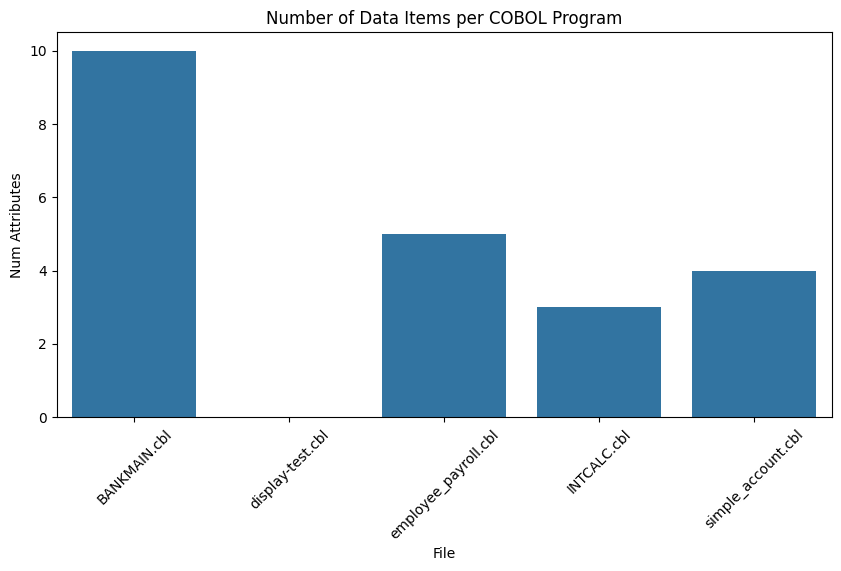

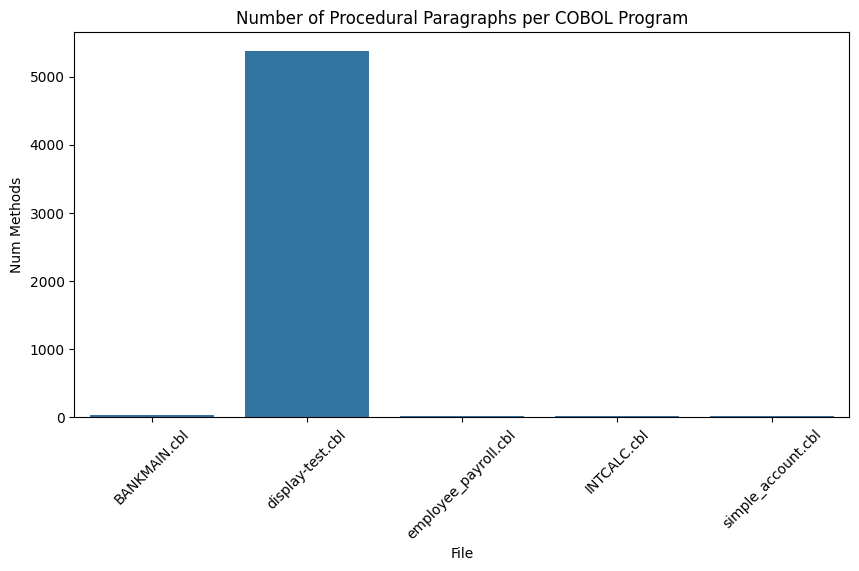

: 

In [ ]:
# Cell 4: Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x='File', y='Num Attributes', data=df)
plt.title('Number of Data Items per COBOL Program')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x='File', y='Num Methods', data=df)
plt.title('Number of Procedural Paragraphs per COBOL Program')
plt.xticks(rotation=45)
plt.show()